# AI Emotion Recognition from Text

## 1. Introduction
This project builds a machine learning model that detects human emotions from text using Natural Language Processing (NLP).



## 2. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 3. Load Dataset

In [ ]:
df = pd.read_csv("training.csv")
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


## 4. Data Exploration

In [ ]:
df.info()
df['label'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB


,count
label,
1,5362
0,4666
3,2159
4,1937
2,1304
5,572


## 5. Data Visualization

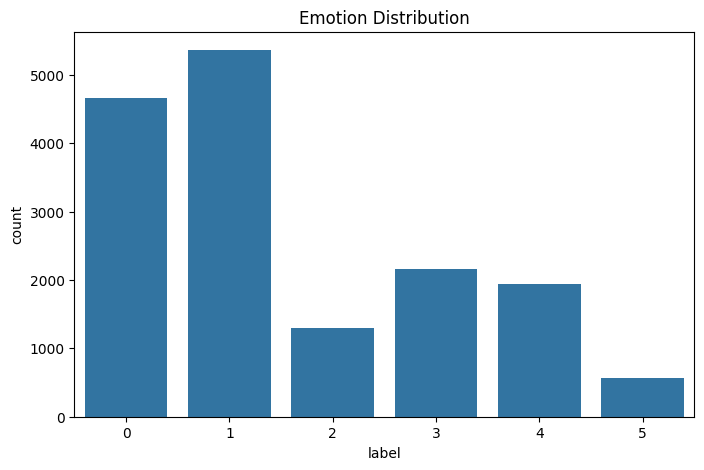

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['label'])
plt.title("Emotion Distribution")
plt.show()


## 6. Feature Extraction (TF-IDF)

In [134]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2),
    stop_words='english'
)
X = vectorizer.fit_transform(df['text'])
y = df['label']


## 7. Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


## 8. Model Training
### 8.1 Logistic Regression

In [124]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=2000)

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=2000)

### 8.2 Support Vector Machine (SVM)

In [125]:
from sklearn.svm import LinearSVC

model = LinearSVC(class_weight="balanced")

model.fit(X_train, y_train)

LinearSVC(class_weight='balanced')

### 8.3 Model Comparison
To determine the best model for emotion classification, we compare the performance of Logistic Regression and Support Vector Machine.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "SVM": LinearSVC()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(name, accuracy_score(y_test, preds))


Logistic Regression 0.8696875


## 9 Model Evaluation
### 9.1 Accuracy

In [ ]:

    from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8990625


In [ ]:
emotion_map = {
    0: "Sadness",
    1: "Joy",
    2: "Love",
    3: "Anger",
    4: "Fear",
    5: "Surprise"
}

In [ ]:
print(emotion_map[1])

Joy


### 9.2  Confusion Matrix


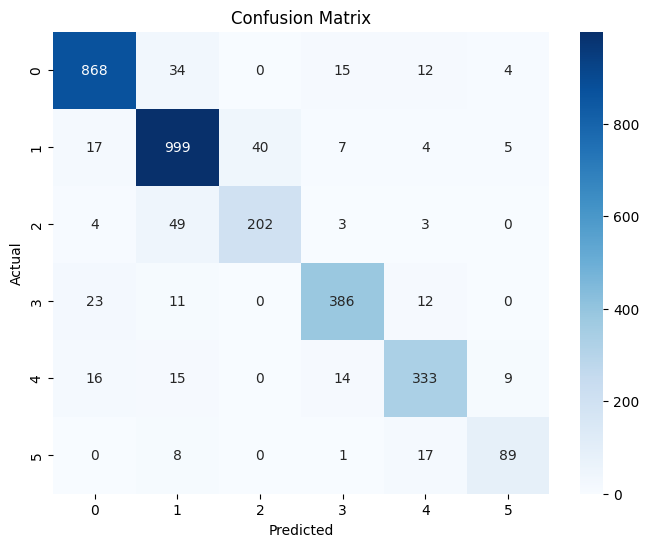

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### 9.3   Classification Report

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93       933
           1       0.90      0.93      0.91      1072
           2       0.83      0.77      0.80       261
           3       0.91      0.89      0.90       432
           4       0.87      0.86      0.87       387
           5       0.83      0.77      0.80       115

    accuracy                           0.90      3200
   macro avg       0.88      0.86      0.87      3200
weighted avg       0.90      0.90      0.90      3200



## 10 Emotion Prediction System
After training the model, we create a function that predicts
the emotion of any input text using the trained classifier.

In [126]:
def predict_emotion(text):

    text_vector = vectorizer.transform([text])

    prediction = model.predict(text_vector)[0]

    return emotion_map[prediction]

In [127]:
predict_emotion("I am feeling amazing today")

'Surprise'

In [128]:
predict_emotion("I am very scared about tomorrow")

'Fear'

## 11 User Input Prediction

In [79]:
user_input = input("Enter a sentence: ")

print("Predicted Emotion:", predict_emotion(user_input))

Enter a sentence: i want a toy i will hit you otherwise
Predicted Emotion: Anger


## 12 Emotion Journey Analyzer
Instead of analyzing a single sentence, this feature analyzes a paragraph sentence by sentence and tracks how emotions evolve throughout the text.

In [80]:
def emotion_journey(paragraph):

    sentences = paragraph.split(".")
    results = []

    for s in sentences:
        s = s.strip()
        if s:
            emotion = predict_emotion(s)
            results.append((s, emotion))

    return results

In [93]:
text = """
I was nervous to start the project.
Then I got scared before the presentation.
After it ended I felt happy and relieved.
it is a haunting journey.
but it is fruitful.
"""



In [94]:
print(emotion_journey(text))

[('I was nervous to start the project', 'Fear'), ('Then I got scared before the presentation', 'Fear'), ('After it ended I felt happy and relieved', 'Joy'), ('it is a haunting journey', 'Love'), ('but it is fruitful', 'Joy')]


## 13 Emotion Journey Visualization

In [85]:
import matplotlib.pyplot as plt
import re

emotion_to_number = {
    "Sadness":0,
    "Joy":1,
    "Love":2,
    "Anger":3,
    "Fear":4,
    "Surprise":5
}

def plot_emotion_journey(paragraph):

    sentences = re.split(r'[.!?]', paragraph)
    emotions = []

    for s in sentences:
        s = s.strip()
        if s:
            emotions.append(predict_emotion(s))

    numbers = [emotion_to_number[e] for e in emotions]

    plt.figure(figsize=(8,4))
    plt.plot(range(len(numbers)), numbers, marker="o")

    plt.title("Emotion Journey Through Text")
    plt.xlabel("Sentence Order")
    plt.ylabel("Emotion")

    plt.yticks(list(emotion_to_number.values()),
               list(emotion_to_number.keys()))

    plt.show()

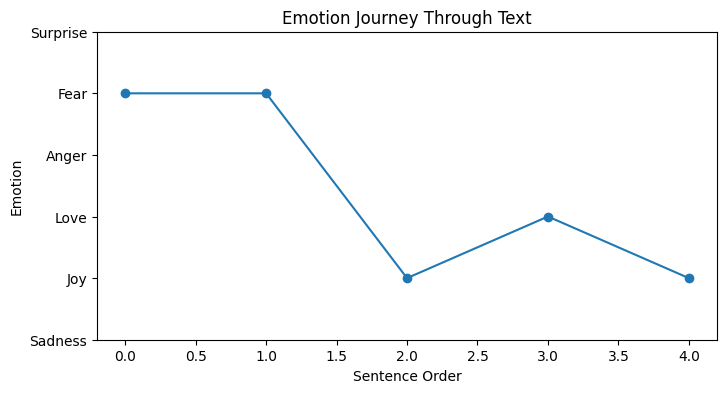

In [95]:
plot_emotion_journey(text)

## 14 Emotion Heatmap Visualization

In [115]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import re

# Mapping emotions to numbers for heatmap coloring
emotion_to_number = {
    "Sadness": 0,
    "Joy": 1,
    "Love": 2,
    "Anger": 3,
    "Fear": 4,
    "Surprise": 5
}

def emotion_heatmap(paragraph):

    # Split paragraph into sentences
    sentences = re.split(r'[.!?]', paragraph)

    emotions_str = []   # emotion names
    emotions_num = []   # numeric values for heatmap

    for s in sentences:
        s = s.strip()
        if s:
            emotion = predict_emotion(s)
            emotions_str.append(emotion)
            emotions_num.append(emotion_to_number[emotion])

    # Create dataframe
    df_heat_num = pd.DataFrame(
        [emotions_num],
        columns=[f"S{i+1}" for i in range(len(emotions_num))]
    )

    df_heat_str = pd.DataFrame(
        [emotions_str],
        columns=[f"S{i+1}" for i in range(len(emotions_str))]
    )

    # Plot heatmap
    plt.figure(figsize=(10,2))

    sns.heatmap(
        df_heat_num,
        annot=df_heat_str,
        fmt="",
        cmap="coolwarm",
        center=2.5,
        cbar=False
    )

    plt.title("Emotion Heatmap Across Sentences")
    plt.xlabel("Sentence Number")
    plt.ylabel("Emotion Pattern")

    plt.show()

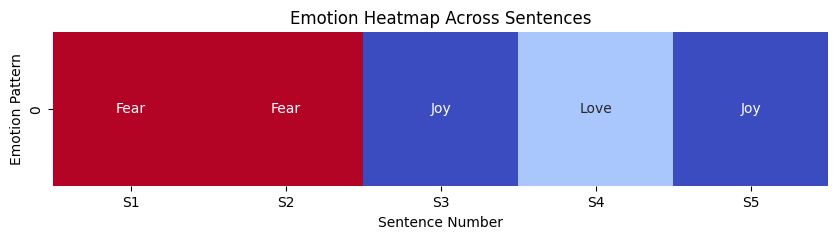

In [116]:
emotion_heatmap(text)

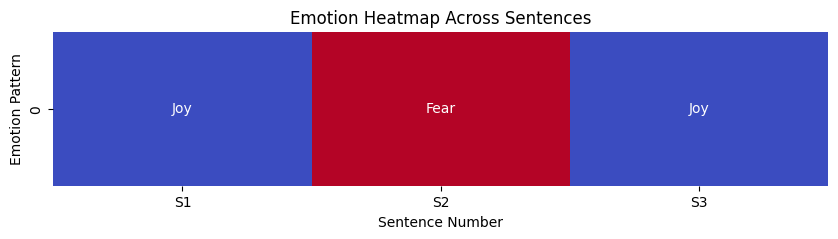

In [117]:
text = """
I was excited to start the project.
Then I got nervous before the presentation.
After it ended I felt happy and relieved.
"""

emotion_heatmap(text)

## 15 Emotion Distribution Visualization

In [100]:
from collections import Counter

def emotion_distribution(paragraph):

    sentences = paragraph.split(".")
    emotions = []

    for s in sentences:
        s = s.strip()
        if s:
            emotions.append(predict_emotion(s))

    count = Counter(emotions)

    plt.figure(figsize=(8,4))
    plt.bar(count.keys(), count.values())

    plt.title("Emotion Distribution in Text")
    plt.xlabel("Emotion")
    plt.ylabel("Frequency")

    plt.show()

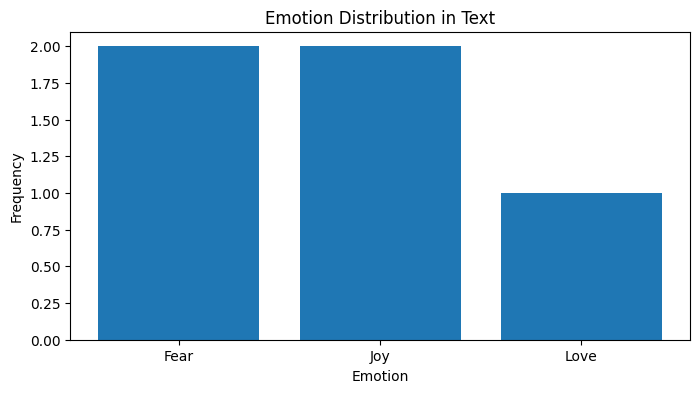

In [101]:
emotion_distribution(text)

## 16 Interactive Emotion Analyzer UI
To make the model interactive, we build a simple user interface using Gradio where users can input text and visualize the emotion predictions.

In [105]:
!pip install gradio

In [121]:
import gradio as gr
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import re
from collections import Counter

emotion_to_number = {
    "Sadness":0,
    "Joy":1,
    "Love":2,
    "Anger":3,
    "Fear":4,
    "Surprise":5
}

def analyze_emotion(paragraph):

    # Overall emotion
    overall_emotion = predict_emotion(paragraph)

    sentences = re.split(r'[.!?]', paragraph)

    emotions = []
    journey_output = []

    for s in sentences:
        s = s.strip()
        if s:
            emotion = predict_emotion(s)
            emotions.append(emotion)
            journey_output.append(f"{s} → {emotion}")

    journey_text = "\n".join(journey_output)

    # Emotion Distribution Plot
    fig1 = plt.figure(figsize=(6,4))
    count = Counter(emotions)

    plt.bar(count.keys(), count.values())
    plt.title("Emotion Distribution")
    plt.xlabel("Emotion")
    plt.ylabel("Frequency")

    # Emotion Heatmap
    numbers = [emotion_to_number[e] for e in emotions]

    df = pd.DataFrame([numbers], columns=[f"S{i+1}" for i in range(len(numbers))])

    fig2 = plt.figure(figsize=(8,2))
    sns.heatmap(df, annot=[emotions], fmt="", cmap="coolwarm", cbar=False)

    plt.title("Emotion Heatmap Across Sentences")

    return overall_emotion, journey_text, fig1, fig2

In [129]:
with gr.Blocks() as demo:

    gr.Markdown("# AI Emotion Analyzer")
    gr.Markdown("Analyze emotional tone and transitions in text using NLP and Machine Learning.")

    text_input = gr.Textbox(
        lines=6,
        label="Enter Paragraph",
        placeholder="Type or paste a paragraph to analyze emotions..."
    )

    analyze_btn = gr.Button("Analyze Emotion")

    emotion_output = gr.Text(label="Overall Emotion")

    journey_output = gr.Textbox(label="Emotion Journey")

    dist_plot = gr.Plot(label="Emotion Distribution")

    heatmap_plot = gr.Plot(label="Emotion Heatmap")

    analyze_btn.click(
        analyze_emotion,
        inputs=text_input,
        outputs=[emotion_output, journey_output, dist_plot, heatmap_plot]
    )

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://8dbcd1467657c2dced.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 17 Save Model

In [130]:
import pickle

pickle.dump(model, open("emotion_model.pkl","wb"))
pickle.dump(vectorizer, open("vectorizer.pkl","wb"))

In [132]:
from google.colab import files

files.download("emotion_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>